**Proyecto II de Programación para Estadística ll**

**Tema:** La evolución del gasto corriente en salud (% del PIB), la pobreza y la incidencia de las enfermedades transmisibles y su variación entre países con diferentes desarrollos económicos durante la última década

**Profesor:** Michael Sanchez Soto

**Estudiantes:** Cyra Coto, Gustavo Jiménez y Abigail Murillo

**Pregunta**

¿Cómo ha evolucionado el gasto corriente en salud (% del PIB), la pobreza y la incidencia de las enfermedades transmisibles durante la última década y de qué manera varía esta relación entre países con diferentes niveles de desarrollo económico?

# 1. CARGA DE LAS BASES DE DATOS

In [ ]:
#Importación de las librerías y carga de los datas frames crudos
import pandas as pd
import numpy as np
import json
from google.colab import files

# -----------------------
# 1. CARGA DE ARCHIVOS RAW
# -----------------------

print("SUBE ARCHIVO DENGUE 1")
uploaded_dengue = files.upload()
df_dengue = pd.read_excel(list(uploaded_dengue.keys())[0])

print("SUBE ARCHIVO HIV")
uploaded_hiv = files.upload()
df_HIV = pd.read_excel(
    list(uploaded_hiv.keys())[0],
    sheet_name="HIV-Test-&-Treat_ByYear",
    engine="openpyxl",
    skiprows=6
)

print("SUBE ARCHIVO INDICE DE POBREZA")
uploaded_pobreza = files.upload()
df_indice_pobreza = pd.read_csv(list(uploaded_pobreza.keys())[0])

print("SUBE ARCHIVO TUBERCULOSIS")
uploaded_tb = files.upload()
df_tuberculosis = pd.read_csv(list(uploaded_tb.keys())[0])

# -----------------------
# 2. CARGA DEL JSON
# -----------------------

print("SUBE ARCHIVO JSON DE GASTO EN SALUD")
uploaded_json = files.upload()
json_filename = list(uploaded_json.keys())[0]
print("JSON cargado:", json_filename)

# Leer JSON correctamente
with open(json_filename, "r", encoding="utf-8") as f:
    data_json = json.load(f)

# Normalizar JSON en DataFrame
df_gasto_salud = pd.json_normalize(data_json)

# -----------------------
# 3. SEGUNDO DATA FRAME DEL DENGUE
# -----------------------

print("SUBE ARCHIVO DENGUE 2")
uploaded_dengue2 = files.upload()
df_dengue2 = pd.read_csv(list(uploaded_dengue2.keys())[0])


SUBE ARCHIVO DENGUE 1


# 2. PREPARACIÓN DE LA BASE DEL DENGUE

In [ ]:
df_dengue.columns #exploracion de las columnas del data frame del dengue

In [ ]:
display(df_dengue) #exploracion del df crudo

In [ ]:
df_dengue.isna().sum() #La base tiene varios varios NA's

In [ ]:
df_dengue.dtypes #Vemos que que las variables están en el formato correcto, además todos los valores faltantes son númericos, por lo que tenemos la posibilidad de sustituirlos con el valor de la mediana


In [ ]:
df_dengue["cases"] = df_dengue["cases"].fillna("No indica")
df_dengue["confirmed_cases"] = df_dengue["confirmed_cases"].fillna("No indica") #LLenamos los valores faltantes con 0 ya que no hay registros
df_dengue["severe_cases"] = df_dengue["severe_cases"].fillna("No indica")
df_dengue["deaths"] = df_dengue["deaths"].fillna("No indica")
df_dengue["cfr"] = df_dengue["cfr"].fillna("Desconocido")
df_dengue["cfr_ci_upper"] = df_dengue["cfr_ci_upper"].fillna("Desconocido") #No sabemos hasta que número podría llegar
df_dengue["cfr_ci_lower"] = df_dengue["cfr_ci_lower"].fillna("Desconocido")
df_dengue["prop_sev"] = df_dengue["prop_sev"].fillna("Desconocido")
df_dengue["prop_sev_ci_lower"] = df_dengue["prop_sev_ci_lower"].fillna("Desconocido")
df_dengue["prop_sev_ci_upper"] = df_dengue["prop_sev_ci_upper"].fillna("Desconocido") #No sabemos hasta que número podría llegar
df_dengue["prop_sev_ci_lower"] = df_dengue["prop_sev_ci_lower"].fillna("Desconocido")



In [ ]:
df_dengue.isna().sum() # Hemos limpiado los NA's

In [ ]:
df_dengue.duplicated().sum() #No posee duplicados

In [ ]:

#Asegúrate de que 'date' sea datetime
df_dengue['date'] = pd.to_datetime(df_dengue['date'])

# Crear columna 'year'
df_dengue['year'] = df_dengue['date'].dt.year


# Convertir 'cases' a numérico, forzando errores a NaN
df_dengue['cases'] = pd.to_numeric(df_dengue['cases'], errors='coerce')

# Agrupar por país y año
df_dengue_final = df_dengue.groupby(['country', 'year'], as_index=False)['cases'].sum()

df_dengue_final.to_excel("dengue.xlsx", index=False)


## 2.2 SEGUNDA BASE DEL DENGUE

In [ ]:
# --- PASO 1: quedarte solo con columnas importantes ---
df_dengue2x = df_dengue2[["adm_0_name", "ISO_A0", "Year", "dengue_total"]]

# --- PASO 2: convertir 'dengue_total' a numérico por si viene como string ---
df_dengue2["dengue_total"] = pd.to_numeric(df_dengue2["dengue_total"], errors="coerce")

# --- PASO 3: agrupar por país y año ---
df_dengue2_final = (
    df_dengue2.groupby(["adm_0_name", "ISO_A0", "Year"], as_index=False)
      .agg(total_cases=("dengue_total", "sum"))
)


df_dengue2_final.rename(columns={
    'adm_0_name': 'country',
    'ISO_A0': 'code',
    'Year': 'year',
    'total_cases': 'dengue_cases'
}, inplace=True)

# Verificar
print(df_dengue2_final.head())



# Resultado final
df_dengue2_final


# 3. PREPARACION DE LA BASE DE LA TUBERCULOSIS

In [ ]:
display(df_tuberculosis)

In [ ]:
df_tuberculosis.isna().sum() #La base posee varios NA's

In [ ]:
df_tuberculosis.dtypes # Todas las variables son del tipo correcto de datos

In [ ]:
df_tuberculosis["Code"] = df_tuberculosis["Code"].fillna("No especifica")

# 4. PREPARACION DE LA BASE GASTOS EN SALUD json

In [ ]:
#Esta base es la de tipo json. requiere un tratamiento especial
#Quitar las primeras filas que no aportan informacion
df_temp = df_gasto_salud.copy()
df_temp = df_temp.iloc[2:].reset_index(drop=True)

#Usar la primera fila como encabezado real
#La nueva fila 0 ahora tiene los nombres reales de columnas (Country Name, Country Code, Indicator Name, 2000, 2001, ...)
new_header = df_temp.iloc[0]
df_temp = df_temp.iloc[1:].reset_index(drop=True)
df_temp.columns = new_header

#Eliminar columnas 'Unnamed' y vacías que hay varias
df_temp = df_temp.loc[:, ~df_temp.columns.astype(str).str.contains(r'^Unnamed', na=False)]
df_temp = df_temp[[c for c in df_temp.columns if str(c).strip() != '' and c is not None]]

#Pasar a formato largo (tidy) year–value o hacer la transposición
#nombres de columnas
rename_map = {
    'Country Name': 'country_name',
    'Country Code': 'country_code',
    'Indicator Name': 'indicator_name',
    'Indicator Code': 'indicator_code'  # por si existiera
}
df_temp = df_temp.rename(columns={k: v for k, v in rename_map.items() if k in df_temp.columns})

#Detectar columnas de año: están como '2000.0', '2001.0',...
def es_col_anio(col):
    s = str(col).strip()
    s = s[:-2] if s.endswith('.0') else s
    return s.isdigit() and len(s) == 4

year_cols = [c for c in df_temp.columns if es_col_anio(c)]
if not year_cols:
    raise ValueError("No se detectaron columnas de año. Revisa los nombres (p.ej. '2000.0').")

#Construir id_vars presentes
id_vars = [c for c in ['country_name', 'country_code', 'indicator_name', 'indicator_code'] if c in df_temp.columns]

df_largo = df_temp.melt(
    id_vars=id_vars,
    value_vars=year_cols,
    var_name='year_raw',
    value_name='value'
)

#Convertir 'year_raw' a 'year' numérico limpio
def limpiar_year(y):
    s = str(y).strip()
    s = s[:-2] if s.endswith('.0') else s
    return pd.to_numeric(s, errors='coerce')

df_largo['year'] = df_largo['year_raw'].apply(limpiar_year)
df_largo.drop(columns=['year_raw'], inplace=True)

#Tipos y limpieza básica
df_largo['value'] = pd.to_numeric(df_largo['value'], errors='coerce')
df_largo = df_largo.dropna(subset=['year', 'value'])

#Quitar filas sin país o con 'None'
if 'country_name' in df_largo.columns:
    df_largo = df_largo[df_largo['country_name'].notna() & (df_largo['country_name'].astype(str).str.strip().str.lower() != 'none')]

#Filtrar el indicador que interesa
target_names = [
    "Gasto corriente en salud (% del PIB)",
    "Current health expenditure (% of GDP)"
]
df_temporal2 = df_largo[df_largo['indicator_name'].isin(target_names)].copy()

#dejar sólo países con código ISO3 (evitar agregados/regiones)
if 'country_code' in df_temporal2.columns:
    df_temporal2 = df_temporal2[df_temporal2['country_code'].astype(str).str.len() == 3]

#Orden final
df_temporal2 = df_temporal2.sort_values(by=['country_name', 'year']).reset_index(drop=True)

out_min = df_temporal2.rename(columns={'country_name': 'pais'})[['pais', 'year', 'value']]

#metadatos útiles para merge:
out_full = df_temporal2.rename(columns={'country_name': 'pais'})[['pais', 'country_code', 'indicator_name', 'year', 'value']]

# Reordenar columnas: country_name, country_code, indicator_name, year, value
cols_order = ['country_name', 'country_code', 'indicator_name', 'year', 'value']
df_gastos_en_salud_final = df_temporal2[cols_order].copy()

#asegurar tipos
df_gastos_en_salud_final['year'] = pd.to_numeric(df_gastos_en_salud_final['year'], errors='coerce').astype('Int64')
df_gastos_en_salud_final['value'] = pd.to_numeric(df_gastos_en_salud_final['value'], errors='coerce')

#Ordenar filas por país, indicador y año
df_gastos_en_salud_final = df_gastos_en_salud_final.sort_values(by=['country_name', 'indicator_name', 'year']).reset_index(drop=True)

# Vista rápida
display(df_gastos_en_salud_final.head(100))



In [ ]:
#Ver si el dataframe tiene valores nulos
df_gastos_en_salud_final.isna().any()


# 5. PREPARACION DE LA BASE INDICE DE POBREZA

In [ ]:
display(df_indice_pobreza)
df_indice_pobreza

In [ ]:
df_indice_pobreza.isna().sum() #La base posee varios NA's

In [ ]:
df_indice_pobreza["ppp"]

In [ ]:
df_indice_pobreza["ppp"].max()

In [ ]:
df_indice_pobreza["ppp"].min()

In [ ]:
mediana_ppp = df_indice_pobreza["ppp"].median() # Utilizamos el valor de la mediana para rellenar valores faltantes

In [ ]:
df_indice_pobreza["watts"] # Watts es una de las columnas que posee NA's
df_indice_pobreza["watts"].max()

In [ ]:
df_indice_pobreza["watts"].min()

In [ ]:
mediana_watts =  df_indice_pobreza["watts"].median()
print(mediana_watts) # Utilizaremos la mediana para estimar rellenar los valores faltantes

In [ ]:
df_indice_pobreza["reporting_pce"] #reporting_pce posee NA's

In [ ]:
df_indice_pobreza["reporting_pce"].max()

In [ ]:
df_indice_pobreza["reporting_pce"].min()

In [ ]:
mediana_pce = df_indice_pobreza["reporting_pce"].median() #Utilizaremos la mediana para estimar los valores faltantes

In [ ]:
df_indice_pobreza["watts"] = df_indice_pobreza["watts"].fillna(df_indice_pobreza["watts"].median())
df_indice_pobreza["ppp"] = df_indice_pobreza["ppp"].fillna(df_indice_pobreza["ppp"].median())
df_indice_pobreza["reporting_pce"] = df_indice_pobreza["reporting_pce"].fillna(df_indice_pobreza["reporting_pce"].median())



In [ ]:
# Por otra parte, la columna "estimate_type" está completamente llena de NA's, por lo que no aporta nada de valor al análisis y es mejor eliminarla completamente.
print(df_indice_pobreza.columns)
df_indice_pobreza
df_indice_pobreza= df_indice_pobreza.drop(columns=["estimation_type"])


In [ ]:
df_indice_pobreza.isna().sum() # Ahora verificamos que el data frame no posee NA's

In [ ]:
df_indice_pobreza.dtypes #Los variables son del tipo que se espera de ellas

In [ ]:
df_indice_pobreza.duplicated().sum() # No tenemos columnas duplicadas

In [ ]:
df_indice_pobreza.head(10)

# 6. Preparacion de la base HIV

In [ ]:
df_HIV_subset = df_HIV.iloc[:, [0, 1, 2] + list(range(78, 83))]  #del data frame solo conservar estas columnas

df_HIV_subset.columns =['Anio', 'codigo', 'pais', 'todas_edades','ninos', 'mujeres', 'hombres', 'adultos'] #asignar un nombre


# Verificar
print(df_HIV_subset.head(5))
print(df_HIV_subset.dtypes)
#df_HIV_subset=df_HIV_subset.apply(pd.to_numeric, errors='coerce') #convertir a tipo numerico
#Verificar por NAs


# Lista de columnas que quieres convertir
cols_numericas = ['todas_edades', 'ninos', 'mujeres', 'hombres', 'adultos']

# Convertir esas columnas a numéricas (coerce convierte errores en NaN)
df_HIV_subset[cols_numericas] = df_HIV_subset[cols_numericas].apply(pd.to_numeric, errors='coerce')

print(df_HIV_subset.dtypes)
df_HIV_subset.isna().sum()
#al ser datos epidemiologicos no manipular NAs


In [ ]:
#PRUEBA DE FUNCIONAIENTO DE LA BASE
df_cr = df_HIV_subset[df_HIV_subset['codigo'] == 'CRI']
df_cr.head(5)


# Agrupar por año y sumar los casos (o cualquier otra agregación)
df_cr_grouped = df_cr.groupby('Anio')[['todas_edades', 'ninos', 'mujeres', 'hombres', 'adultos']].sum().reset_index()

# Verificar
print(df_cr_grouped)


# 7 UNIFICACIÓN DE LAS BASES

In [ ]:
#REVISION FINAL DE LOS DATA FRAMES

#df_dengue_final.head(5)
#df_tuberculosis.head(5)
#df_gasto_salud.head(6)
#df_indice_pobreza.head(5)
df_HIV_subset.head(5)


In [ ]:

# Renombrar columnas para consistencia
df_tuberculosis.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Estimated number of new cases of all forms of tuberculosis': 'tb_cases'
}, inplace=True)

df_HIV_subset.rename(columns={
    'Anio': 'year',
    'pais': 'country',
    'todas_edades': 'hiv_cases'
}, inplace=True)



# Merge progresivo por country y year
df_merge = df_dengue2_final.merge(df_tuberculosis[['country', 'year', 'tb_cases']],
                                 on=['country', 'year'], how='outer')

df_merge = df_merge.merge(df_HIV_subset[['country', 'year', 'hiv_cases']],
                           on=['country', 'year'], how='outer')

# Ordenar
df_merge.sort_values(['country', 'year'], inplace=True)

print(df_merge.head())


# Verificar
print(df_merge.head(20))



df_merge.to_excel("dengue2.xlsx", index=False)



In [ ]:
#merge de las bases con datos economicos


# Seleccionar solo las columnas deseadas
df_indice_pobreza = df_indice_pobreza[['country_name', 'country_code', 'reporting_year', 'ppp']]

# Verificar resultado
print(df_indice_pobreza.head())


# Renombrar columnas
df_indice_pobreza.rename(columns={
    'country_name': 'country',
    'country_code': 'code',
    'reporting_year': 'year',
    'ppp': 'ppp'
}, inplace=True)

# Verificar
print(df_indice_pobreza.head())





In [ ]:

# Seleccionar solo las columnas deseadas
df_gastos_en_salud_final = df_gastos_en_salud_final[['country_name', 'country_code', 'year', 'value']]

# Renombrar para consistencia
df_gastos_en_salud_final.rename(columns={
    'country_name': 'country',
    'country_code': 'code',
    'year': 'year',
    'value': 'value'
}, inplace=True)

# Verificar
print(df_gastos_en_salud_final.head())


In [ ]:

# Normalizar nombres de país para evitar problemas
df_gastos_en_salud_final['country'] = df_gastos_en_salud_final['country'].str.strip().str.upper()
df_indice_pobreza['country'] = df_indice_pobreza['country'].str.strip().str.upper()

# Merge por country y year
df_economicos = df_gastos_en_salud_final.merge(
    df_indice_pobreza[['country', 'code', 'year', 'ppp']],
    on=['country', 'year'],
    how='outer'  # puedes usar 'inner' si solo quieres coincidencias exactas
)

# Verificar resultado
print(df_economicos.head(20))


In [ ]:
print(df_indice_pobreza[['country', 'year', 'ppp']].head(20))

In [ ]:

# Consolidar df_merge (sumar casos numéricos)
df_merge = df_merge.groupby(['country', 'year'], as_index=False).sum(numeric_only=True)

# Consolidar df_economicos (promedio o primer valor)
df_economicos = df_economicos.groupby(['country', 'year'], as_index=False).mean(numeric_only=True)

# Merge final
df_unificado = df_merge.merge(df_economicos, on=['country', 'year'], how='outer')

# Filtrar años entre 2010 y 2024
df_unificado = df_unificado[(df_unificado['year'] >= 2010) & (df_unificado['year'] <= 2024)]

# Ordenar y exportar
df_unificado.sort_values(['country', 'year'], inplace=True)


df_unificado.head(10)



In [ ]:
regiones_banco_mundial = {
    "america del norte": "North America",
    "america latina y el caribe": "Latin America & Caribbean",
    "america latina y el caribe (birf y la aif)": "Latin America & Caribbean",
    "america latina y el caribe (excluido altos ingresos)": "Latin America & Caribbean",
    "asia meridional": "South Asia",
    "asia meridional (birf y la aif)": "South Asia",
    "asia oriental y el pacifico": "East Asia & Pacific",
    "asia oriental y el pacifico (birf y la aif)": "East Asia & Pacific",
    "asia oriental y el pacifico (excluido altos ingresos)": "East Asia & Pacific",
    "africa": "Africa",
    "africa al sur del sahara": "Sub-Saharan Africa",
    "africa al sur del sahara (birf y la aif)": "Sub-Saharan Africa",
    "africa al sur del sahara (excluido altos ingresos)": "Sub-Saharan Africa",
    "medio oriente y norte de africa": "Middle East & North Africa",
    "middle east and north africa": "Middle East & North Africa",
    "oriente medio y norte de africa (birf y la aif)": "Middle East & North Africa",
    "oriente medio y norte de africa (excluido altos ingresos)": "Middle East & North Africa",
    "europa y asia central": "Europe & Central Asia",
    "europa y asia central (birf y la aif)": "Europe & Central Asia",
    "europa y asia central (excluido altos ingresos)": "Europe & Central Asia",
    "europa central y del baltico": "Europe & Central Asia",
    "caribbean": "Caribbean",
    "asian and pacific": "Asia & Pacific",
    "south america": "South America",
    "north america": "North America",
    "eastern and southern africa": "Sub-Saharan Africa",
    "western and central africa": "Sub-Saharan Africa",
    "eastern europe and central asia": "Europe & Central Asia",
    "western and central europe and north america": "High Income",
}
grupos_ingreso = {
    "ingreso alto": "High income",
    "ingreso mediano": "Middle income",
    "ingreso mediano alto": "Upper middle income",
    "ingreso mediano y bajo": "Lower middle income",
    "paises de ingreso bajo": "Low income",
    "paises de ingreso mediano bajo": "Lower middle income",
    "high-income countries": "High income",
    "low-income countries": "Low income",
    "upper-middle-income countries": "Upper middle income",
    "lower-middle-income countries": "Lower middle income",
}
otros_grupos = {
    "global": "World",
    "world": "World",
    "mundo": "World",
    "zona del euro": "Eurozone",
    "union europea": "European Union",
    "el mundo arabe": "Arab World",
    "miembros ocde": "OECD members",
    "solo birf": "IBRD only",
    "solo aif": "IDA only",
    "total de la aif": "IDA total",
    "fragiles y situaciones de conflicto afectados": "Fragile & conflict-affected",
    "paises menos desarrollados: clasificacion de las naciones unidas": "Least developed countries",
    "pequenos estados": "Small States",
    "otros estados pequeos": "Small States",
}
paises_mal_escritos = {
    "alemania": "Germany",
    "arabia saudita": "Saudi Arabia",
    "argelia": "Algeria",
    "azerbaiyan": "Azerbaijan",
    "belgica": "Belgium",
    "birf y la aif": None,
    "brasil": "Brazil",
    "cabo verde": "Cape Verde",
    "camboya": "Cambodia",
    "camerun": "Cameroon",
    "chipre": "Cyprus",
    "colombia": "Colombia",
    "comoras": "Comoros",
    "congo, republica del": "Congo",
    "congo, republica democratica del": "Democratic Republic of the Congo",
    "corea, republica de": "South Korea",
    "cote divoire": "Côte d'Ivoire",
    "dinamarca": "Denmark",
    "egipto, republica arabe de": "Egypt",
    "emiratos arabes unidos": "United Arab Emirates",
    "espana": "Spain",
    "estados unidos": "United States",
    "etiopia": "Ethiopia",
    "federacion de rusia": "Russia",
    "filipinas": "Philippines",
    "francia": "France",
    "gambia, the": "Gambia",
    "granada": "Grenada",
    "grecia": "Greece",
    "guinea ecuatorial": "Equatorial Guinea",
    "hungria": "Hungary",
    "india": "India",
    "iran, islamic rep.": "Iran",
    "iran, republica islamica del": "Iran",
    "irlanda": "Ireland",
    "islandia": "Iceland",
    "italia": "Italy",
    "japon": "Japan",
    "jordania": "Jordan",
    "kazajstan": "Kazakhstan",
    "kirguistan": "Kyrgyzstan",
    "letonia": "Latvia",
    "libano": "Lebanon",
    "lituania": "Lithuania",
    "luxemburgo": "Luxembourg",
    "macedonia del norte": "North Macedonia",
    "malasia": "Malaysia",
    "maldivas": "Maldives",
    "marruecos": "Morocco",
    "mauricio": "Mauritius",
    "mexico": "Mexico",
    "mongolia": "Mongolia",
    "mozambique": "Mozambique",
    "nicaragua": "Nicaragua",
    "noruega": "Norway",
    "nueva zelandia": "New Zealand",
    "paises bajos": "Netherlands",
    "panama": "Panama",
    "paraguay": "Paraguay",
    "peru": "Peru",
    "polonia": "Poland",
    "portugal": "Portugal",
    "qatar": "Qatar",
    "reino unido": "United Kingdom",
    "republica centroafricana": "Central African Republic",
    "republica checa": "Czech Republic",
    "republica dominicana": "Dominican Republic",
    "republica arabe siria": "Syria",
    "rumania": "Romania",
    "senegal": "Senegal",
    "singapur": "Singapore",
    "sudafrica": "South Africa",
    "suecia": "Sweden",
    "suiza": "Switzerland",
    "syria": "Syria",
    "tailandia": "Thailand",
    "taiwan, china": "Taiwan",
    "tunez": "Tunisia",
    "turquia": "Turkey",
    "ucrania": "Ukraine",
    "uruguay": "Uruguay",
    "uzbekistan": "Uzbekistan",
    "venezuela": "Venezuela",
    "viet nam": "Vietnam",
    "yemen, rep.": "Yemen",
    "zambia": "Zambia",
    "zimbabwe": "Zimbabwe"
}


In [ ]:

!pip install Unidecode country_converter
import pandas as pd
import unidecode
import country_converter as coco
df_unificado["country_clean"] = (
    df_unificado["country"]
    .astype(str)
    .str.lower()
    .str.strip()
    .apply(unidecode.unidecode)
)

manual_map = {}
manual_map.update(regiones_banco_mundial)
manual_map.update(grupos_ingreso)
manual_map.update(otros_grupos)
manual_map.update(paises_mal_escritos)

df_unificado["country_fixed"] = df_unificado["country_clean"].replace(manual_map)

mask_convertible = df_unificado["country_fixed"].notna()

df_unificado.loc[mask_convertible, "country_estandar"] = coco.convert(
    df_unificado.loc[mask_convertible, "country_fixed"].tolist(),
    to="name_short", not_found = None)




In [ ]:
df_unificado["country_estandar"].value_counts()

In [ ]:
df_unificado["country"] = df_unificado["country_estandar"]
df_unificado = df_unificado.drop(columns=[
    "country_clean",
    "country_fixed",
    "country_estandar"
], errors="ignore")

In [ ]:
df_unificado

1. Python y Programación básica

In [ ]:
df_unificado.dtypes #Como podemos ver tenemos distintos tipos de datos, tenemos string, float e int.

In [ ]:
df_unificado["country"].value_counts() #Tenemos bastantes valores únicos
lista_paises = ["Zimbabwe","Zambia","Gabon"] # Podemos hacer una lista con 3 países africanos.
dic_enfermedades = {
    "Zimbabwe": {"Continente":"Africa"},
    "Zambia": {"Continente":"Africa"},
    "Gabon": {"Continente":"Africa"},  #Creamos un diccionario con los continentes de los países seleccionados
    "Jordan": {"Continente": "Asia"},
    "Vanuatu": {"Continente": "Oceania"},
}

conjunto_paises = set(["VIRGIN ISLANDS(US)","VIRGIN ISLANDS(UK)","VIRGIN ISLANDS(US)", "Algeria"])
print(conjunto_paises)


In [ ]:
clasificaciones = []

for idx, fila in df_unificado.iterrows():
    casos = fila["dengue_cases"]

    if pd.isna(casos):
        clasificaciones.append("Sin información")

    elif casos < 1000:
        clasificaciones.append("Pocos casos")

    elif 1000 <= casos <= 10000:
        clasificaciones.append("Varios casos")

    elif casos > 10000:
        clasificaciones.append("Muchos casos")

pd.Series(clasificaciones).value_counts()

In [ ]:
paises = df_unificado["country"].unique()

for pais in paises:
    df_pais = df_unificado[df_unificado["country"] == pais].sort_values("year")

    i = 0
    encontrado = False

    while i < len(df_pais):
        casos = df_pais.iloc[i]["dengue_cases"]

        if casos > 10000:
            anio = df_pais.iloc[i]["year"]
            print(f"{pais}: primer año con >10,000 casos es {anio}")
            encontrado = True
            break

        i += 1

    if not encontrado:
        print(f"{pais}: nunca superó los 10,000 casos")


In [ ]:
def total_casos(df, pais, anio):
    fila = df[(df["country"] == pais) & (df["year"] == anio)]

    if fila.empty:
        return None

    total = (
        fila["dengue_cases"].fillna(0).sum() +
        fila["hiv_cases"].fillna(0).sum() +
        fila["tb_cases"].fillna(0).sum()
    )
    return total


total_casos(df_unificado,"cuba", 2010)


In [ ]:
class Pais:
    def __init__(self, nombre, df):
        """
        Crea un objeto país.
        - nombre: string con el nombre del país.
        - df: DataFrame con todas las observaciones.
        """
        self.nombre = nombre
        self.df = df[df["country"] == nombre]  # Filtra solo ese país

    def casos_totales_anio(self, anio):
        fila = self.df[self.df["year"] == anio]

        if fila.empty:
            return None

        total = (
            fila["dengue_cases"].fillna(0).sum() +
            fila["hiv_cases"].fillna(0).sum() +
            fila["tb_cases"].fillna(0).sum()
        )
        return total

    def resumen(self):
        """
        Devuelve un diccionario con total de casos por año.
        """
        resumen = {}
        for anio in sorted(self.df["year"].unique()):
            resumen[anio] = self.casos_totales_anio(anio)
        return resumen


In [ ]:
venezuela = Pais("venezuela",df_unificado)
venezuela.casos_totales_anio(2010)

In [ ]:
df_unificado["dengue_cases"].max()

4.4 Visualización

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Creamos una nueva columna la cual tiene la transformación de "ppp" a logarítmo
df_indice_pobreza['ppp_log'] = np.log1p(df_indice_pobreza['ppp'])

#Valores bajos (0 a 5):países con PPP muy bajo
#Valores medios (5 a 10): países con PPP moderado
#Valores altos (10 a +20):países con PPP muy alto o extremos

#Los calculamos de esta manera porque necesitamos dividir en tres ya que vamos a hacer ingreso alto, medio y bajo
cuartil1 = df_indice_pobreza['ppp_log'].quantile(0.33)
cuartil2 = df_indice_pobreza['ppp_log'].quantile(0.66)

#Clasificación según nivel de ingreso
def clasificar_nivel_ingreso(valor_log):
    if valor_log <= cuartil1:
        return 'Ingreso bajo'
    elif valor_log <= cuartil2:
        return 'Ingreso medio'
    else:
        return 'Ingreso alto'

df_indice_pobreza['nivel_ingreso'] = df_indice_pobreza['ppp_log'].apply(clasificar_nivel_ingreso)

#Verificamos la distribución de categorías
print(df_indice_pobreza['nivel_ingreso'].value_counts())

#Creación del boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df_indice_pobreza, x='nivel_ingreso', y='ppp_log')
plt.title('Distribución de PPP (log) por nivel de ingreso')
plt.ylabel('PPP (log)')
plt.xlabel('Nivel de ingreso')
plt.show()


# Interpretaciones
1.El gráfico muestra la distribución de Paridad Poder Adquisitivo (PPA) en escala logarítmica
# Países de ingreso alto
La caja es más grande, lo que significa mayor variabilidad entre países de ingreso alto.
Existencia de valores atípicos indicando que algunos países de ingreso alto tienen un PPP muy superficial al resto
# Países de ingreso medio
La caja es pequeña , lo que indica que hay menos variación interna (los países se parecen más entre sí)
# Países de ingreso bajo
Tiene los valores de PPA más pequeños de todo el gráfico.
La caja es muy pequeña, lo que indica similitud de PPA entre países de ingresos bajos

# Conclusiones generales
El PPA y la variabilidad disminuyen según el nivel de ingreso.
El análisis refleja que los países de ingreso alto tienen economías con mayor capacidad de compra a diferencia de los países de menos ingreso ya que tienen economías más limitadas, reflejando así una desigualdad significativa



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar años válidos si no lo hiciste antes
df_salud_filtrado = df_unificado[df_unificado['year'].between(2010, 2024)]

# Graficar evolución temporal del gasto en salud
plt.figure(figsize=(10,6))
sns.lineplot(data=df_salud_filtrado, x='year', y='value')
plt.title('Evolución del gasto en salud por año')
plt.ylabel('Gasto en salud')
plt.xlabel('Año')
plt.grid(True)
plt.show()


# Interpretaciones
El gráfico muestra una línea temporal sobre el promedio del gasto en salud desde el 2010 hasta el 2023
Se observa que entre el 2010 y el 2019 hay un crecimiento suave y progresivo en el gasto en salud.
Desde el 2019 se puede notar un incremento en el gasto en salud, esto pudo haber sido debido a la pandemia.
En el 2022 se observa una caída temporal, lo que significa que algunos países redujeron el gasto, probablemente tras la fase crítica de la pandemia.
En el 2023 se observa un crecimiento muy grande en el gasto en salud, esto puede deberse a ajustes económicos


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Limpieza de datos
df_merge['country'] = df_merge['country'].str.strip().str.title()

# Eliminar entradas que no son países reales
excluir = ['Africa', 'Asia', 'Europe', 'Oceania', 'World']
df_merge = df_merge[~df_merge['country'].isin(excluir)]

#Calcular promedios
df_promedio = df_merge.groupby('country')[['tb_cases','hiv_cases','dengue_cases']].mean().reset_index()

#Eliminar países con todos los valores en cero
df_promedio = df_promedio[(df_promedio[['tb_cases','hiv_cases','dengue_cases']] != 0).any(axis=1)]

#Calcular total de casos promedio por país
df_promedio['total'] = df_promedio[['tb_cases','hiv_cases','dengue_cases']].sum(axis=1)

#Seleccionar los 10 países con más casos promedio
top10 = df_promedio.nlargest(10, 'total')

#Reorganizar para graficar
df_promedio_melt = top10.melt(
    id_vars='country',
    value_vars=['tb_cases','hiv_cases','dengue_cases'],
    var_name='enfermedad',
    value_name='casos'
)

#Creación del gráfico
plt.figure(figsize=(12,6))
sns.barplot(data=df_promedio_melt, x='country', y='casos', hue='enfermedad')
plt.title('Top 10 países con más casos promedio por enfermedad')
plt.ylabel('Casos promedio')
plt.xlabel('País')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# Interpretaciones
El gráfico muestra un ranking de los 10 países con mayor cantidad promedio de casos en 3 enfermedades: tuberculosis, VIH y dengue
Países que destacan por tuberculosis
Lower-Middle-Income-Countries es el país que tiene la barra azul más alta de todo el gráfico, lo que indica que tiene los mayores casos promedio de tuberculosis (más de 6 millones).
Upper-Middle-Income-Countries tiene el segundo lugar con casi 3 millones.
La tuberculosis es la enfermedad más prevalente en países de ingresos medios, superando por mucho el VIH y dengue
# País donde el VIH es más alto
South Africa presenta uno de los valores más altos del gráfico con más de 3 millones, lo que indica que tiene una de las epidemias de VIH más grandes
# País donde el dengue es más alto
La India es el único país en el gráfico donde el dengue aparece con una cifra visible
# Conclusiones generales
La tuberculosis es la enfermedad que predomina en el gráfico, luego sigue VIH que es la enfermedad predominante en África y por último el dengue, que es el que presenta menos casos


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar datos válidos
df_dengue = df_merge.dropna(subset=['dengue_cases'])

# Seleccionar 10 países aleatorios con datos
paises_dengue = df_dengue['country'].dropna().unique()
paises_seleccionados = pd.Series(paises_dengue).sample(8, random_state=70).tolist()

df_dengue_filtrado = df_dengue[df_dengue['country'].isin(paises_seleccionados)]

# Crear tabla pivote
tabla_dengue = df_dengue_filtrado.pivot_table(
    index='country',
    columns='year',
    values='dengue_cases',
    aggfunc='sum'
)

# Graficar heatmap
plt.figure(figsize=(12,6))
sns.heatmap(tabla_dengue, cmap='YlOrRd', linewidths=0.5)
plt.title('Mapa de calor de casos de dengue (10 países aleatorios)')
plt.xlabel('Año')
plt.ylabel('País')
plt.show()



# Interpretaciones
El mapa de calor evidencia diferencias claras en la distribución temporal del dengue entre países.
Camboya muestra múltiples brotes severos a lo largo del tiempo, destacándose como el país con mayor carga de enfermedad en este subconjunto.
Singapur presenta actividad sostenida y brotes relevantes especialmente desde la década del 2000.
Papua New Guinea reporta casos ocasionales, mientras que países como Bélgica, Italia, Guinea, Madagascar y Tanzania mantienen niveles cercanos a cero en la mayoría de los años.
En conjunto, el gráfico refleja que la incidencia del dengue se concentra principalmente en países tropicales del sudeste asiático, con patrones de brotes recurrentes y marcados contrastes respecto a regiones no endémicas.


**4.5**Mapas

In [ ]:
import geopandas as gpd
import pandas as pd
import folium

world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")
world = world.rename(columns={"NAME": "country"})


df_unificado["total_cases"] = (
    df_unificado["dengue_cases"].fillna(0) +
    df_unificado["hiv_cases"].fillna(0) +
    df_unificado["tb_cases"].fillna(0)
)

df_totales = df_unificado.groupby(["country", "year"], as_index=False)["total_cases"].sum()

def mapa_por_anio(anio):

    df_anio = df_totales[df_totales["year"] == anio]

    mapa_gdf = world.merge(df_anio, on="country", how="left")

    m = folium.Map(location=[20, 0], zoom_start=2)

    folium.Choropleth(
        geo_data=mapa_gdf,
        name="choropleth",
        data=mapa_gdf,
        columns=["country", "total_cases"],
        key_on="feature.properties.country",
        fill_color="YlOrRd",
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name=f"Total de casos en {anio}"
    ).add_to(m)

    folium.LayerControl().add_to(m)

    return m

mapa_por_anio(2020)


4.6 Estadística descriptiva y simulación


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#Normalizamos los nombres de los país
df_merge['country'] = df_merge['country'].str.strip().str.title()

#Eliminamos entradas no válidas
excluir = ['Africa', 'Asia', 'Europe', 'Oceania', 'World']
df_merge = df_merge[~df_merge['country'].isin(excluir)]

#Filtramos países con al menos un dato válido
df_filtrado = df_merge[(df_merge[['tb_cases','hiv_cases','dengue_cases']] != 0).any(axis=1)]

#Estadística descriptiva por país
desc = df_filtrado.groupby('country')[['tb_cases','hiv_cases','dengue_cases']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

#Percentiles 25 y 75
percentiles = df_filtrado.groupby('country')[['tb_cases','hiv_cases','dengue_cases']].quantile([0.25, 0.75]).unstack()

#Mostrar resumen para primeros países
print("Medidas descriptivas:")
print(desc.head(5))
print("\nPercentiles:")
print(percentiles.head(5))

In [ ]:
#CORRELACIÓN ENTRE INDICADORES
corr = df_filtrado[['tb_cases','hiv_cases','dengue_cases']].dropna().corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre enfermedades')
plt.show()

# Interpretaciones
El siguiente gráfico muestra una correlación entre enfermedades

# Correlación de Pearson
1 Correlación positiva (cuando una variable aumenta la otra también)
-1 Correlación negativa (cuando una variable aumenta la otra disminuye)
0 sin correlación lineal

# Correlación entre casos de Tuberculosis y VIH
El número de casos de tuberculosis y el número de casos de VIH tienen una relación lineal muy pequeña en los datos analizados. Un aumento en los casos de una no está fuertemente asociado con un aumento en los casos de la otra
# Correlación entre casos de Tuberculosis y Dengue
Indica una correlación negativa extremadamente débil (casi nula), no hay una relación lineal significativa entre los casos de tuberculosis y los casos de dengue
# Correlación entre casos de VIH y Dengue
El valor es extremadamente cercano a cero y negativo. Indica una correlación negativa extremadamente débil (casi nula), no hay una relación lineal significativa entre los casos de VIH y los casos de dengue
# Conclusión general
El análisis de esta matriz de correlación sugiere que, según los datos utilizados para generar el gráfico, no existe una relación lineal significativa entre el número de casos de estas tres enfermedades.


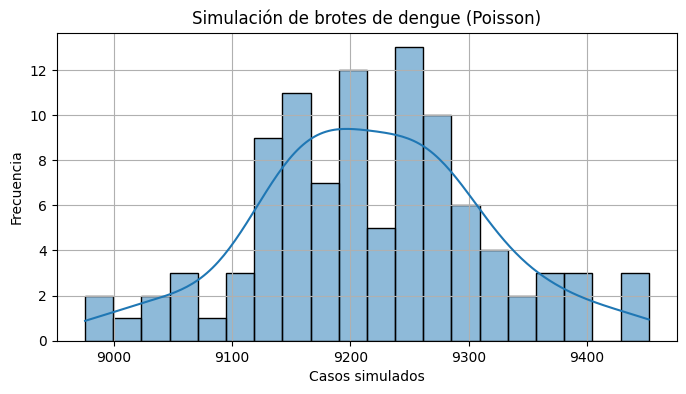

In [80]:
media_dengue = df_filtrado['dengue_cases'].dropna().mean()

# Simulación con distribución Poisson
simulacion_dengue = np.random.poisson(lam=media_dengue, size=100)

plt.figure(figsize=(8,4))
sns.histplot(simulacion_dengue, bins=20, kde=True)
plt.title('Simulación de brotes de dengue (Poisson)')
plt.xlabel('Casos simulados')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

7. Shiny para Python

In [ ]:
df_unificado

In [ ]:
#Ngrok
!wget -O ngrok-stable-linux-amd64.zip https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-stable-linux-amd64.zip

#Descomprimir
!unzip -o ngrok-stable-linux-amd64.zip

#Agregar token
!./ngrok authtoken "35dA5fQ2MPWXb9yIoIftFTwzo5w_2NS7konAe3x4HgShe61xk"

#Permiso de ejecución
!chmod +x ngrok

#Ngrok en segundo plano
import subprocess
import time

process = subprocess.Popen(["./ngrok", "http", "8000"])
time.sleep(3)

#Obtener URL pública

import requests

try:
    tunnels = requests.get("http://localhost:4040/api/tunnels").json()
    public_url = tunnels["tunnels"][0]["public_url"]
    print("URL pública de tu Shiny:", public_url)
except Exception as e:
    print("No se pudo obtener la URL:", e)


In [ ]:
!wget -O ngrok-stable-linux-amd64.zip https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-stable-linux-amd64.zip

!unzip -o ngrok-stable-linux-amd64.zip #descomprimir ngrok

!./ngrok authtoken "35dA5fQ2MPWXb9yIoIftFTwzo5w_2NS7konAe3x4HgShe61xk" #agregar token de ngrok

!chmod +x ngrok #permiso de ejecución

#iniciar ngrok en segundo plano
import subprocess
import time

process = subprocess.Popen(["./ngrok", "http", "8000"])
time.sleep(3)

#Obtener la URL pública
import requests

try:
    tunnels = requests.get("http://localhost:4040/api/tunnels").json()
    public_url = tunnels["tunnels"][0]["public_url"]
    print("URL pública de tu Shiny:", public_url)
except Exception as e:
    print("No se pudo obtener la URL:", e)


In [ ]:
!pip install shiny
from shiny import App, ui, render, reactive
import pandas as pd
import matplotlib.pyplot as plt

df = df_unificado
df = df.sort_values(["country", "year"])

app_ui = ui.page_navbar(

    ui.nav_panel(
        "Dashboard",

        ui.layout_sidebar(

            ui.sidebar(
                ui.h3("Filtros"),

                ui.input_select(
                    "pais",
                    "País:",
                    sorted(df["country"].dropna().unique())
                ),

                ui.input_slider(
                    "year_range",
                    "Rango de años:",
                    min(df["year"]),
                    max(df["year"]),
                    value=(min(df["year"]), max(df["year"]))
                ),

                ui.input_select(
                    "indicador",
                    "Indicador:",
                    {
                        "dengue_cases": "Casos de Dengue",
                        "tb_cases": "Casos de Tuberculosis",
                        "hiv_cases": "Casos de VIH",
                        "value": "PPP (World Bank)",
                        "ppp": "PPP Alternativo"
                    }
                )
            ),

            ui.h3("Tabla de Datos"),
            ui.output_table("tabla"),

            ui.h3("Gráfico del Indicador"),
            ui.output_plot("grafico")
        )
    ),

    ui.nav_panel(
        "Descripción",
        ui.p("""
        Esta aplicación permite visualizar indicadores de salud y PPP
        filtrados por país e intervalo de años usando Shiny para Python.
        """)
    ),

    title="Dashboard Salud & PPP"
)

def server(input, output, session):

    @reactive.Calc
    def datos_filtrados():
        d = df[df["country"] == input.pais()]
        yr_low, yr_high = input.year_range()
        d = d[(d["year"] >= yr_low) & (d["year"] <= yr_high)]
        return d

    @output
    @render.table
    def tabla():
        return datos_filtrados()[["country", "year", input.indicador()]]

    @output
    @render.plot
    def grafico():
        d = datos_filtrados()
        indicador = input.indicador()

        fig, ax = plt.subplots()
        ax.plot(d["year"], d[indicador], marker="o")
        ax.set_title(f"{indicador} en {input.pais()}")
        ax.set_xlabel("Año")
        ax.set_ylabel(indicador)
        ax.grid(True)
        return fig

app = App(app_ui, server)

app.run()

In [ ]:
app.run()
